<a href="https://colab.research.google.com/github/RachmadAprisandhy/PembelajaranMesin/blob/main/JS06/JS06_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

lab 2 Klasifikasi SVM dengan Data Dummy Non-Linier

1. Ilustrasi Data Non-Linier

1a. Import Library

In [1]:
	# import library
	import numpy as np
	import matplotlib.pyplot as plt
	from scipy import stats
	import seaborn as sns
	from sklearn.svm import SVC

1b. Buat Kembali Fungsi Plotting

In [5]:
	# buat sebuah fungsi untuk menampilkan fitting data

	def plot_svc_decision_function(model, ax=None, plot_support=True):

	    if ax is None:
	        ax = plt.gca()
	    xlim = ax.get_xlim()
	    ylim = ax.get_ylim()

	    # buat grid untuk evaluasi model
	    x = np.linspace(xlim[0], xlim[1], 30)
	    y = np.linspace(ylim[0], ylim[1], 30)
	    Y, X = np.meshgrid(y, x)
	    xy = np.vstack([X.ravel(), Y.ravel()]).T
	    P = model.decision_function(xy).reshape(X.shape)

	    # plot batas dan margin
	    ax.contour(X, Y, P, colors='k',
	               levels=[-1, 0, 1], alpha=0.5,
	               linestyles=['--', '-', '--'])

	    # plot support vectors
	    if plot_support:
	        ax.scatter(model.support_vectors_[:, 0],
	                   model.support_vectors_[:, 1],
	                   s=300, linewidth=1, facecolors='none');
	    ax.set_xlim(xlim)
	    ax.set_ylim(ylim)

1c. buat data dummy non-liner

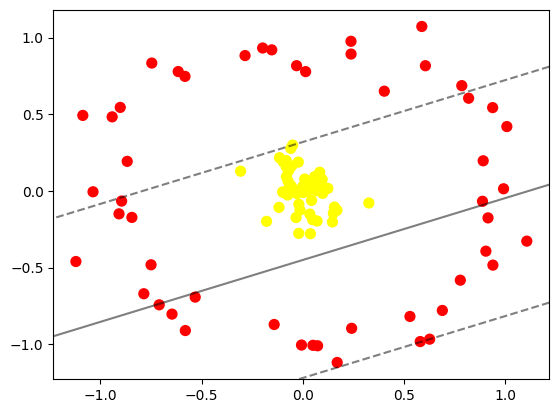

In [7]:
	# contoh data tidak terpisah secara linier
	from sklearn.datasets import make_circles
	X, y = make_circles(100, factor=.1, noise=.1)

	clf = SVC(kernel='linear').fit(X, y)

	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf, plot_support=False);

In [8]:
r = np.exp(-(X**2).sum(1))

plot visualisasi 3d

In [9]:
	from mpl_toolkits import mplot3d
	from ipywidgets import interact, fixed

	def plot_3D(elev=30, azim=30, X=X, y=y):
	    ax = plt.subplot(projection='3d')
	    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
	    ax.view_init(elev=elev, azim=azim)
	    ax.set_xlabel('x')
	    ax.set_ylabel('y')
	    ax.set_zlabel('r')

	interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
	         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-5.32087568e-01, -6.93029666e-01],
       [ 8.36814514e-02,  2.97699742e-02],
       [ 9.38588815e-01, -4.84342972e-01],
       [-5.58315019e-02,  1.61958711e-01],
       [ 9.52608480e-02,  7.51253789e-02],
       [-8.22588323e-02,  1.97551040e-01],
       [ 9.09629691e-03,  7.73995465e-02],
       [-5.98738999e-02,  2.77376082e-01],
       [ 1.10606417e+00, -3.27788918e-01],
       [ 4.27246868e-02, -6.21027150e-02],
       [-9.72955248e-02, -9.91297922e-03],
       [-1.03686570e+00, -5.82617797e-03],
       [ 1.55840042e-01, -1.05491993e-01],
       [ 9.14445981e-01, -1.76018512e-01],
       [-7.33076288e-02,  6.32340723e-02],
       [ 1.50208054e-01, -1.46153343e-01],
       [-9.02396337e-01,  5.44897007e-01],
       [-6.61459170e-06,  2.90386151e-02],
       [-5.82507632e-01,  7.47302460e-01],
       [ 9.37357604e-01,  5.43491256e-01],
       [-9.42332136e-01,  4.83225308e-01],
       [ 4.80662022e-02, -1.87777577e-01],
       [-2.05124836e-02, -2.77236953e-01],
       [ 8.87098716e-01, -6.78000608e-02],
       [-1.08729875e+00,  4.92648395e-01],
       [-1.15512040e-01,  2.16569479e-01],
       [ 5.80466260e-02,  9.30881073e-02],
       [-9.08472588e-01, -1.49781546e-01],
       [ 8.90598257e-01,  1.96539464e-01],
       [-4.76494678e-02,  1.24916010e-02],
       [-6.46677801e-01, -8.04119354e-01],
       [-8.25247134e-02,  1.59418018e-01],
       [ 1.34335283e-02,  7.78388201e-01],
       [-7.50203852e-01, -4.82179854e-01],
       [-2.85842241e-01,  8.83098894e-01],
       [ 6.05174470e-01,  8.16901245e-01],
       [-1.41956419e-01, -8.71876165e-01],
       [-3.12313175e-02,  8.17038791e-01],
       [ 3.42039404e-02, -1.51196109e-01],
       [ 4.02080731e-01,  6.50682028e-01],
       [-9.83194671e-02,  1.91543434e-01],
       [ 1.69278502e-01, -1.11968764e+00],
       [ 5.79581736e-01, -9.83300706e-01],
       [-7.46555568e-01,  8.34264511e-01],
       [-1.53888009e-01,  9.20398276e-01],
       [ 5.28755699e-01, -8.19282002e-01],
       [ 2.37529015e-01,  9.76219245e-01],
       [ 6.61057938e-02,  1.64904294e-03],
       [ 2.37812561e-01,  8.92979337e-01],
       [ 1.68159212e-01, -1.26267646e-01],
       [-6.63493352e-02,  2.28563268e-02],
       [ 1.23262699e-01,  1.62930929e-02],
       [-5.80649370e-01, -9.11272962e-01],
       [ 8.18620474e-01,  6.04684271e-01],
       [ 7.00404662e-02, -1.96480004e-01],
       [ 6.26157018e-01, -9.67574803e-01],
       [-1.45545687e-02, -1.25211006e-01],
       [ 8.60804140e-02,  2.37201571e-02],
       [ 3.69363678e-02, -2.79475334e-01],
       [-6.16046325e-01,  7.78710830e-01],
       [ 7.77651737e-01, -5.82653501e-01],
       [-1.99423298e-02, -8.72603851e-02],
       [ 9.76197954e-02, -1.58907662e-02],
       [ 4.75657973e-02,  3.51483128e-02],
       [-8.68009215e-01,  1.92753202e-01],
       [ 3.25713376e-01, -7.88806531e-02],
       [ 1.00751534e+00,  4.19883680e-01],
       [ 9.91196616e-01,  1.38327620e-02],
       [ 7.84959811e-01,  6.86806836e-01],
       [-1.00122836e-01, -6.46126273e-03],
       [ 9.03935919e-01, -3.93264611e-01],
       [ 2.40761591e-01, -8.96800622e-01],
       [ 5.87460304e-01,  1.07296073e+00],
       [ 2.58107021e-03, -1.03181748e-02],
       [-2.90042590e-02, -1.75652599e-02],
       [-8.95610783e-01, -6.63833307e-02],
       [-7.11193603e-02,  1.32037648e-01],
       [-8.15656276e-02,  9.33099870e-02],
       [-1.12149125e+00, -4.60886676e-01],
       [ 8.30148347e-02,  1.21886096e-01],
       [ 2.21342936e-02, -1.20233699e-03],
       [-3.37765793e-02, -1.73728200e-01],
       [-7.09918810e-01, -7.43368843e-01],
       [ 1.45905884e-01, -2.02479157e-01],
       [-7.85842732e-01, -6.71119972e-01],
       [-2.27483064e-02,  1.87823150e-01],
       [-5.85591737e-02,  3.35322504e-02],
       [-3.07858630e-01,  1.28745195e-01],
       [-1.79563428e-01, -1.98526432e-01],
       [ 7.25932337e-02, -1.01068756e+00],
       [-8.44906328e-01, -1.72969554e-01],
       [ 6.88804062e-01, -7.80180635e-01

2. Fitting Model

kernel radial basis function (RBF) pada Scikit-Learn digunakan.

In [10]:
	clf = SVC(kernel='rbf', C=1E6)
	clf.fit(X, y)

SVC(C=1000000.0)

Plot hasil decision boundaries dari kernel RBF

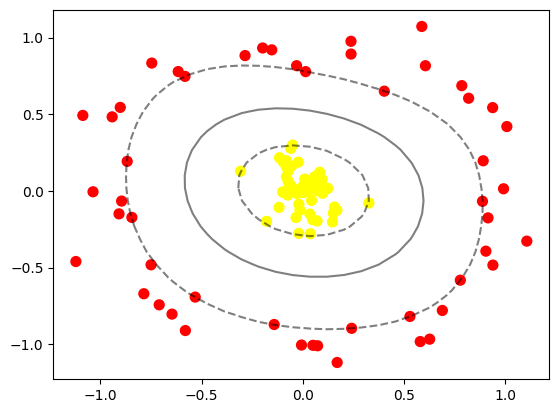

In [11]:
	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf)
	plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
	            s=300, lw=1, facecolors='none')